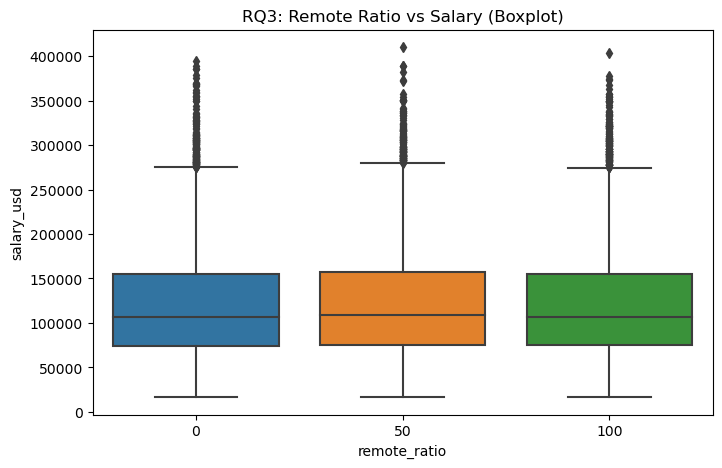

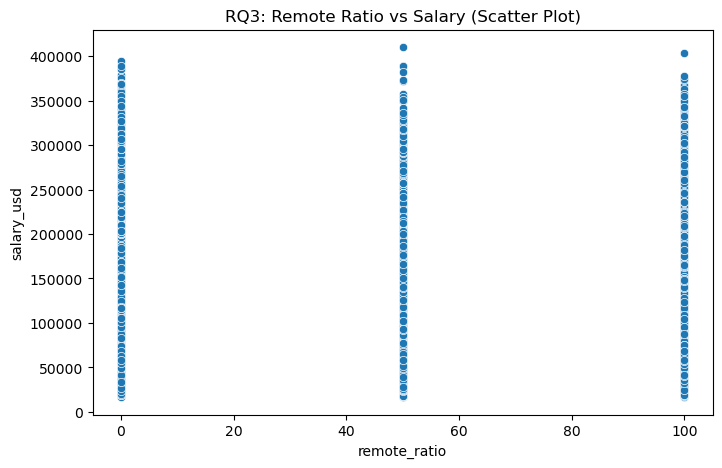

   remote_ratio  Average_Salary  Median_Salary  Count       Std_Dev
0             0   121581.708744       106506.0   4975  64060.824656
1            50   122260.912643       108528.0   4991  64040.659679
2           100   122130.682956       107069.5   5034  63815.712385

ANOVA Result:
   F-Statistic  P-Value
0     0.158247  0.85364

Regression Results:
            MAE  R2_Score  Coefficient      Intercept
0  49790.926302 -0.000071     7.490964  121688.516053

RQ3 completed successfully!
Files saved in E:\ML ASSIGNMENT 2


In [1]:

# RQ3: Remote Work vs Salary


import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

from scipy.stats import f_oneway

df = pd.read_csv("ai_job_dataset1.csv")

data = df[['remote_ratio', 'salary_usd']].dropna()

model_path = r"E:\ML ASSIGNMENT 2\models"
table_path = r"E:\ML ASSIGNMENT 2\tables"

os.makedirs(model_path, exist_ok=True)
os.makedirs(table_path, exist_ok=True)

data.to_csv(r"E:\ML ASSIGNMENT 2\rq3_remote_salary_dataset.csv", index=False)

plt.figure(figsize=(8,5))
sns.boxplot(x='remote_ratio', y='salary_usd', data=data)
plt.title("RQ3: Remote Ratio vs Salary (Boxplot)")
plt.savefig(f"{model_path}/RQ3_boxplot.png", dpi=300)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='remote_ratio', y='salary_usd', data=data)
plt.title("RQ3: Remote Ratio vs Salary (Scatter Plot)")
plt.savefig(f"{model_path}/RQ3_scatter.png", dpi=300)
plt.show()

summary_table = data.groupby('remote_ratio').agg(
    Average_Salary=('salary_usd', 'mean'),
    Median_Salary=('salary_usd', 'median'),
    Count=('salary_usd', 'count'),
    Std_Dev=('salary_usd', 'std')
).reset_index()

print(summary_table)

summary_table.to_csv(f"{table_path}/RQ3_remote_salary_summary.csv", index=False)

groups = [group['salary_usd'].values for name, group in data.groupby('remote_ratio')]

anova_result = f_oneway(*groups)

anova_table = pd.DataFrame({
    "F-Statistic": [anova_result.statistic],
    "P-Value": [anova_result.pvalue]
})

anova_table.to_csv(f"{table_path}/RQ3_anova_results.csv", index=False)

print("\nANOVA Result:")
print(anova_table)

X = data[['remote_ratio']]
y = data['salary_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

model_results = pd.DataFrame({
    "MAE": [mae],
    "R2_Score": [r2],
    "Coefficient": [model.coef_[0]],
    "Intercept": [model.intercept_]
})

model_results.to_csv(f"{table_path}/RQ3_regression_results.csv", index=False)

print("\nRegressiol_results)
n Results:")
print(mode

with open(f"{table_path}/RQ3_conclusion.txt", "w") as f:
    if anova_result.pvalue < 0.05:
        f.write("Remote work ratio significantly affects salary levels.\n")
    else:
        f.write("Remote work ratio does NOT significantly affect salary levels.\n")

print("\nRQ3 completed successfully!")
print("Files saved in E:\\ML ASSIGNMENT 2")